# Mutual Fund Industry EDA Analysis

This notebook performs exploratory data analysis on mutual fund industry datasets from 2022–2025.

Objectives:
- NAV Analysis
- AUM Analysis
- SIP Analysis
- Investor Analysis
- Sector Analysis
- Correlation Analysis

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [38]:
# Load Datasets

fund_df = pd.read_csv("../data/raw/01_fund_master.csv")
nav_df = pd.read_csv("../data/raw/02_nav_history.csv")
aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

In [58]:
# Additional datasets

category_df = pd.read_csv("../data/raw/05_category_inflows.csv")
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")
investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")
holding_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [59]:
category_df.columns
folio_df.columns
investor_df.columns
holding_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [60]:
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")
category_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [61]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")
folio_df.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [62]:
investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")
investor_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [39]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [40]:
aum_df['date'] = pd.to_datetime(aum_df['date'])

aum_df['year'] = aum_df['date'].dt.year

In [41]:
aum_df['year'].unique()

array([2022, 2023, 2024, 2025], dtype=int32)

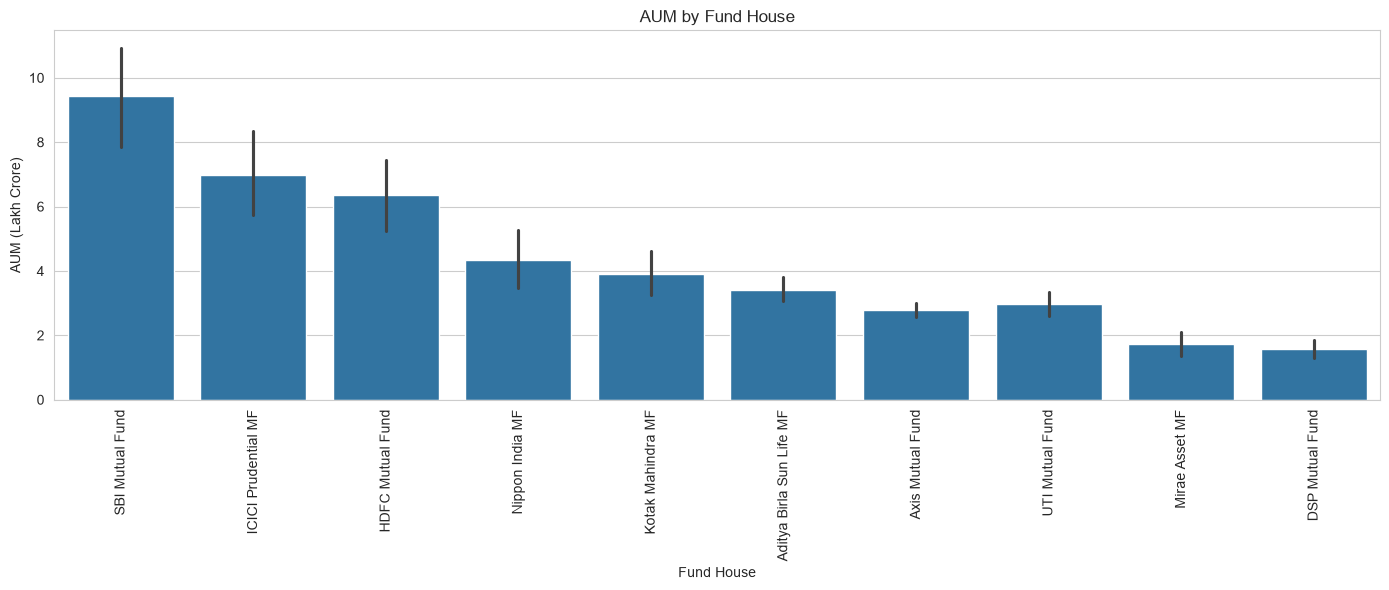

In [42]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.xlabel("Fund House")

plt.ylabel("AUM (Lakh Crore)")

plt.tight_layout()

plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2. AUM Growth Analysis

The Assets Under Management (AUM) of various fund houses were analyzed. The chart shows the distribution of AUM across different fund houses.

In [43]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [44]:
sip_df['month'] = pd.to_datetime(sip_df['month'])

In [45]:
fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend'
)

fig.show()

In [46]:
max_row = sip_df.loc[
    sip_df['sip_inflow_crore'].idxmax()
]

fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True
)

fig.show()

In [47]:
fig.write_image("../charts/sip_trend.png")

TypeError: Type is not JSON serializable: Timestamp

In [ ]:
TypeError                                 Traceback (most recent call last)
TypeError: Type is not JSON serializable: Timestamp

The above exception was the direct cause of the following exception:

TypeError                                 Traceback (most recent call last)
Cell In[31], line 1
----> 1 fig.write_image("../charts/sip_trend.png")

File d:\Data Analyst Internship\Bluestock_MF_Capstone\venv\Lib\site-packages\plotly\basedatatypes.py:3895, in BaseFigure.write_image(self, *args, **kwargs)
   3891     if kwargs.get("engine", None):
   3892         warnings.warn(
   3893             ENGINE_PARAM_DEPRECATION_MSG, DeprecationWarning, stacklevel=2
   3894         )
-> 3895 return pio.write_image(self, *args, **kwargs)

File d:\Data Analyst Internship\Bluestock_MF_Capstone\venv\Lib\site-packages\plotly\io\_kaleido.py:530, in write_image(fig, file, format, scale, width, height, validate, engine)
    526 format = infer_format(path, format)
    528 # Request image
    529 # Do this first so we don't create a file if image conversion fails
--> 530 img_data = to_image(
    531     fig,
    532     format=format,

SyntaxError: invalid syntax (294597291.py, line 1)

In [ ]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

nav_df = pd.read_csv("../data/raw/02_nav_history.csv")

aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category_df = pd.read_csv("../data/raw/05_category_inflows.csv")

folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance_df = pd.read_csv("../data/raw/07_scheme_performance.csv")

investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")

holding_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [ ]:
nav_df.head()
nav_df.info()
nav_df.columns

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


Index(['amfi_code', 'date', 'nav'], dtype='str')

In [ ]:
nav_df.isnull().sum()
aum_df.isnull().sum()
sip_df.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [ ]:
nav_df.drop_duplicates(inplace=True)

aum_df.drop_duplicates(inplace=True)

sip_df.drop_duplicates(inplace=True)

In [ ]:
nav_df.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [ ]:
aum_df.columns


Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [ ]:
sip_df.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [ ]:
print("NAV Columns:")
print(nav_df.columns)

print("\nAUM Columns:")
print(aum_df.columns)

print("\nSIP Columns:")
print(sip_df.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [ ]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

aum_df['date'] = pd.to_datetime(aum_df['date'])

sip_df['month'] = pd.to_datetime(sip_df['month'])

In [ ]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [ ]:
fund_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [ ]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

In [ ]:
nav_merged = nav_df.merge(
    fund_df[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [ ]:
nav_merged.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [ ]:
top_funds = nav_merged['scheme_name'].unique()[:10]

In [ ]:
nav_top = nav_merged[
    nav_merged['scheme_name'].isin(top_funds)
]

In [ ]:
import plotly.express as px

fig = px.line(
    nav_top,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend (2022-2026)'
)

fig.show()

In [ ]:
fig.write_image("../charts/nav_trend.png")

NameError: name 'fig' is not defined

In [ ]:
import plotly.express as px

In [ ]:
fig = px.line(
    nav_top,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend (2022–2026)'
)

fig.show()

NameError: name 'nav_top' is not defined

In [ ]:
nav_df['date'] = pd.to_datetime(nav_df['date'])


NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [ ]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

nav_df = pd.read_csv("../data/raw/02_nav_history.csv")

In [ ]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

In [ ]:
nav_merged = nav_df.merge(
    fund_df[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

In [ ]:
top_funds = nav_merged['scheme_name'].unique()[:10]

nav_top = nav_merged[
    nav_merged['scheme_name'].isin(top_funds)
]

In [ ]:
fig = px.line(
    nav_top,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend (2022–2026)'
)

fig.show()

In [ ]:
fig.write_image("../charts/nav_trend.png")

FileNotFoundError: [Errno 2] No such file or directory: '..\\charts\\nav_trend.png'

In [ ]:
import os
os.getcwd()

'd:\\Data Analyst Internship\\Bluestock_MF_Capstone\\notebooks'

In [ ]:
import os

os.makedirs("../charts", exist_ok=True)

In [ ]:
os.listdir("..")

['.git',
 '.gitignore',
 '.vscode',
 'bluestock_mf.db',
 'charts',
 'dashboard',
 'data',
 'notebooks',
 'README.md',
 'reports',
 'requirements.txt',
 'scripts',
 'sql',
 'venv']

In [ ]:
fig.write_image("../charts/nav_trend.png")

## 1. NAV Trend Analysis

The daily NAV movement of selected mutual fund schemes was analyzed from 2022 to 2026. The chart shows the performance trends of multiple schemes over time.

In [ ]:
aum_df.head()

NameError: name 'aum_df' is not defined

In [ ]:
aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [ ]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
aum_df['date'] = pd.to_datetime(aum_df['date'])

aum_df['year'] = aum_df['date'].dt.year

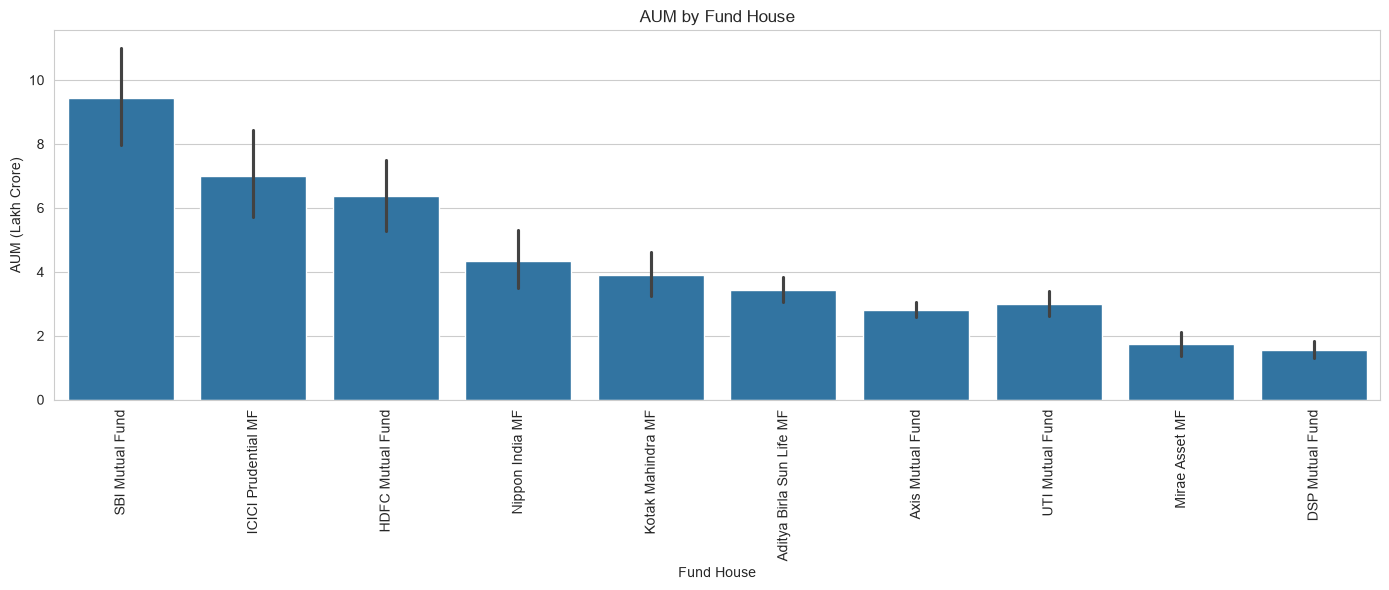

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.xlabel("Fund House")

plt.ylabel("AUM (Lakh Crore)")

plt.tight_layout()

plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend'
)

In [ ]:
max_row = sip_df.loc[
    sip_df['sip_inflow_crore'].idxmax()
]

fig.add_annotation(
    x=str(max_row['month'].date()),
    y=max_row['sip_inflow_crore'],
    text=f"Peak: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True
)

fig.show()

In [ ]:
fig.write_image("../charts/sip_trend.png")

In [ ]:
investor_df.columns

NameError: name 'investor_df' is not defined

## 3. SIP Inflow Analysis

The SIP inflow trend shows consistent growth in retail investments. The peak monthly SIP contribution indicates strong investor participation in mutual funds.

In [48]:
import os

os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis.csv',
 'HDFC.csv',
 'ICICI.csv',
 'Kotak.csv',
 'Nippon.csv',
 'SBI.csv']

In [49]:
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")

In [50]:
category_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [51]:
folio_df.head()

NameError: name 'folio_df' is not defined

In [52]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [53]:
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [54]:
folio_df.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [55]:
category_df = pd.read_csv("../data/raw/05_category_inflows.csv")
category_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [56]:
investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")
investor_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [57]:
holding_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
holding_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [63]:
category_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [64]:
folio_df.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [65]:
investor_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [66]:
category_df['month'] = pd.to_datetime(category_df['month'])

category_pivot = category_df.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

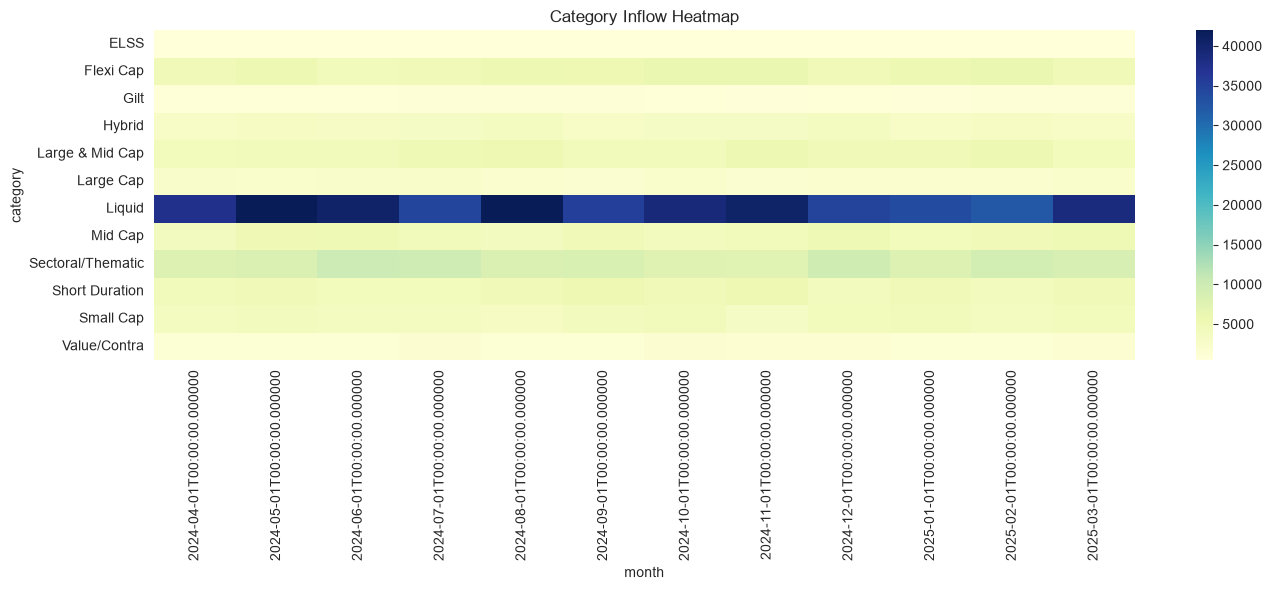

In [67]:
plt.figure(figsize=(14,6))

sns.heatmap(
    category_pivot,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    "../charts/category_heatmap.png",
    dpi=300
)

plt.show()

In [68]:
folio_df['month'] = pd.to_datetime(folio_df['month'])

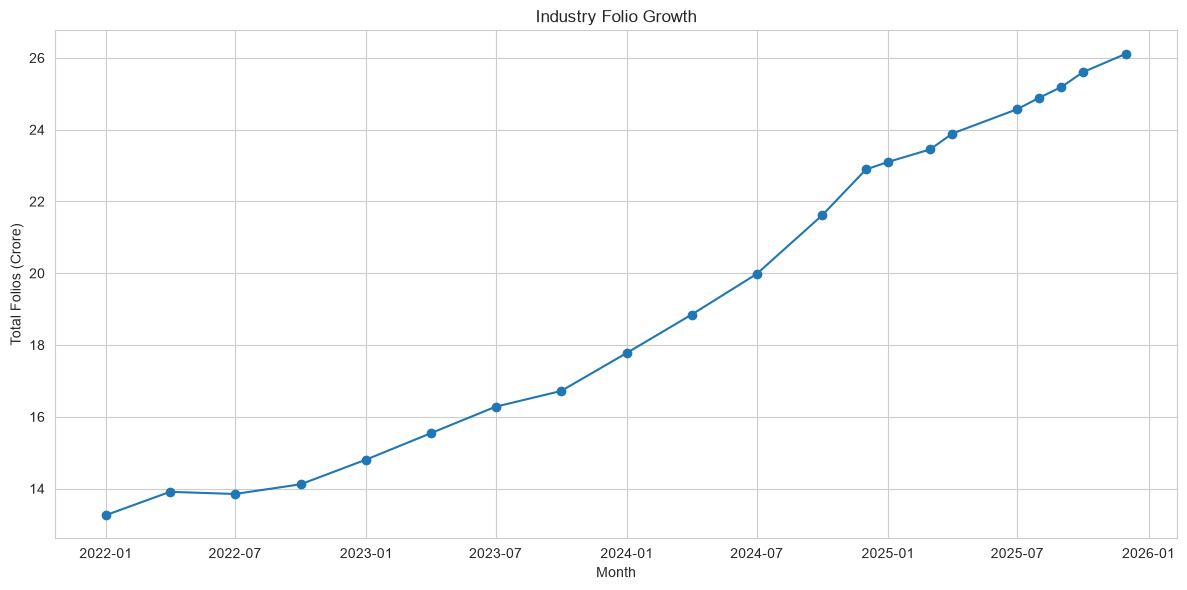

In [69]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df['month'],
    folio_df['total_folios_crore'],
    marker='o'
)

plt.title("Industry Folio Growth")

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../charts/folio_growth.png",
    dpi=300
)

plt.show()

In [70]:
sector_data = holding_df.groupby(
    'sector'
)['weight_pct'].sum()

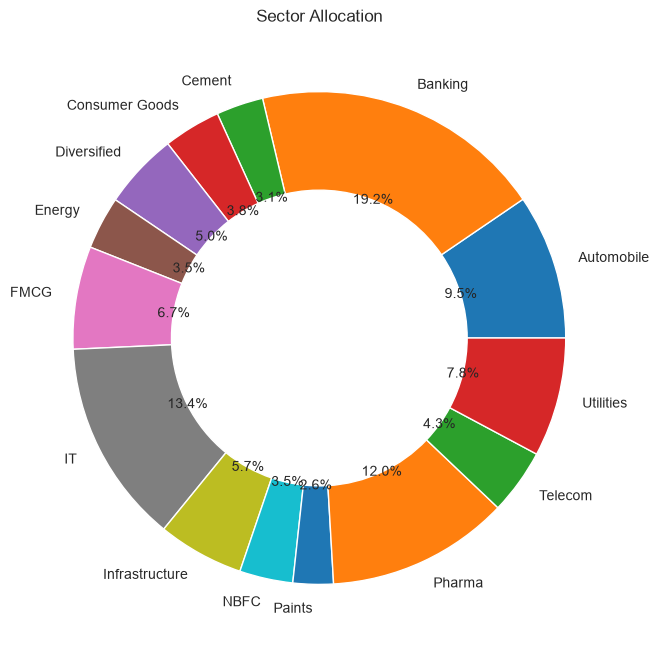

In [71]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%',
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation")

plt.savefig(
    "../charts/sector_allocation.png",
    dpi=300
)

plt.show()

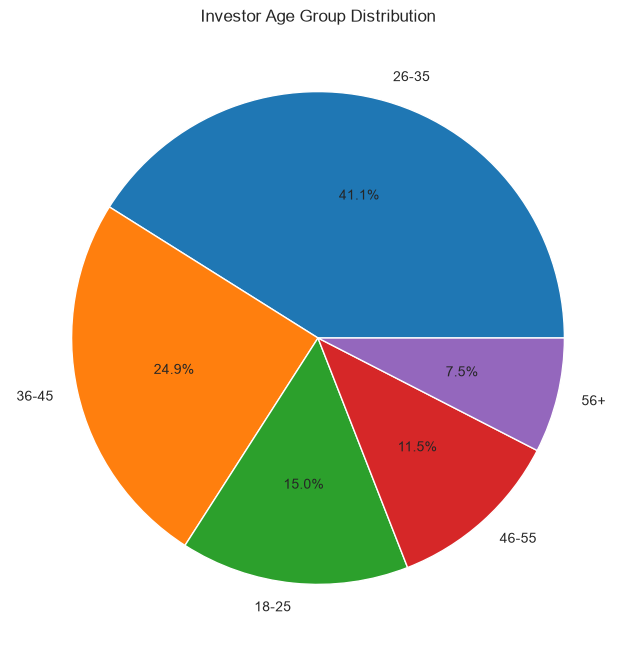

In [72]:
age_counts = investor_df['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../charts/age_distribution.png",
    dpi=300
)

plt.show()

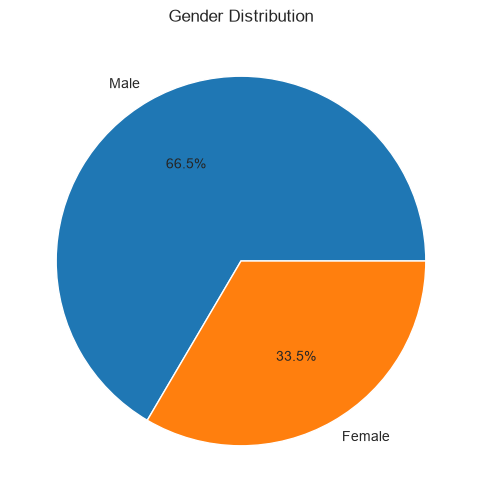

In [73]:
gender_counts = investor_df['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.savefig(
    "../charts/gender_distribution.png",
    dpi=300
)

plt.show()

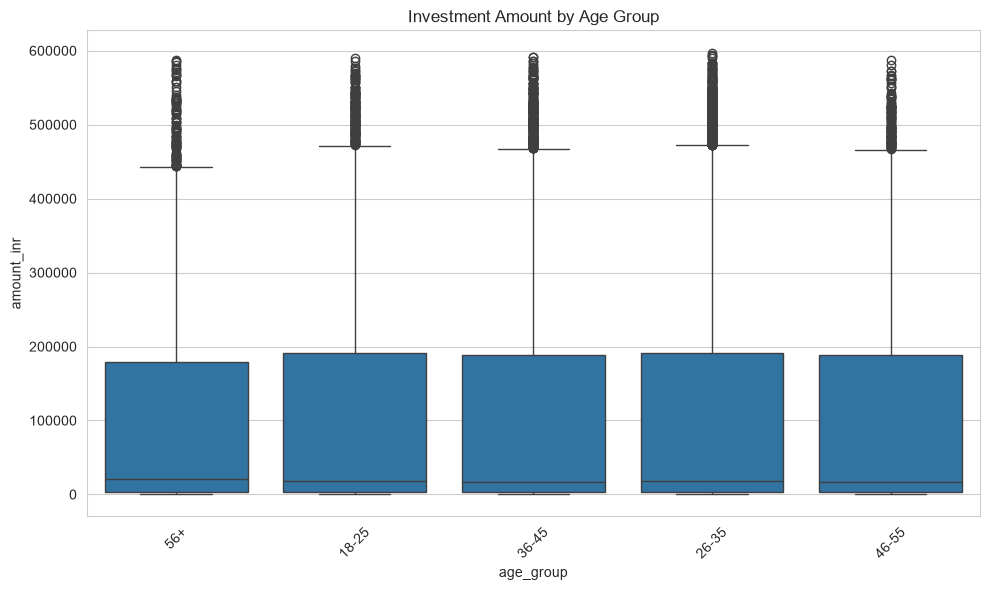

In [74]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor_df,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount by Age Group")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/age_boxplot.png",
    dpi=300
)

plt.show()

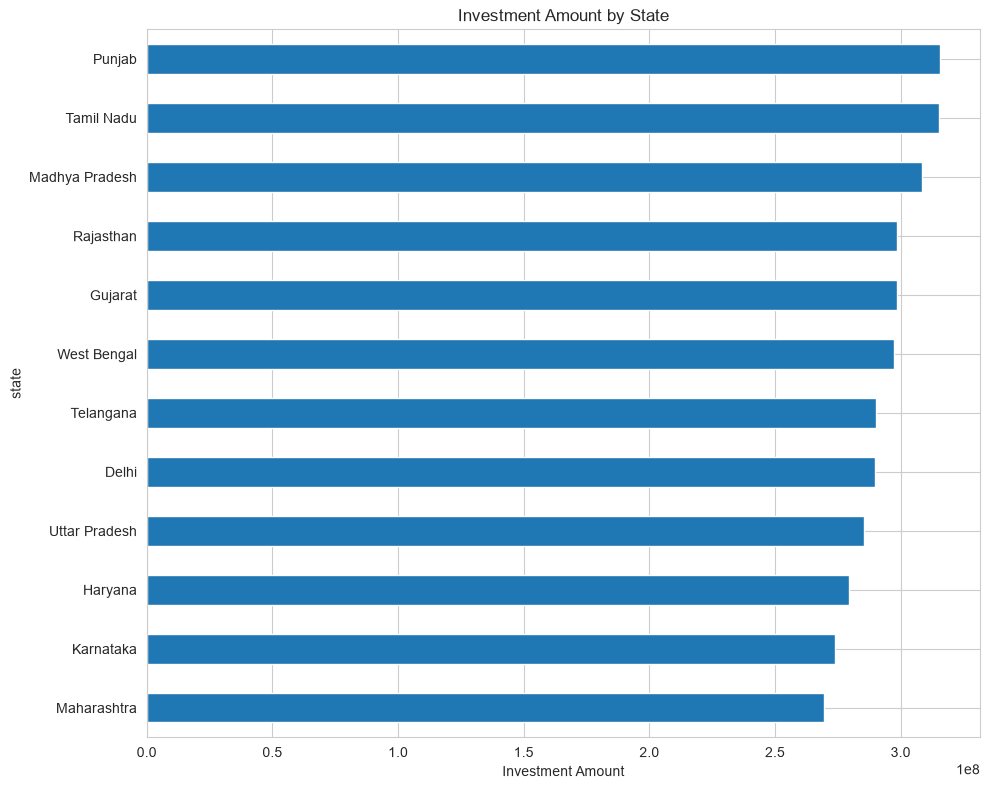

In [75]:
state_data = investor_df.groupby(
    'state'
)['amount_inr'].sum().sort_values()

plt.figure(figsize=(10,8))

state_data.plot(kind='barh')

plt.title("Investment Amount by State")

plt.xlabel("Investment Amount")

plt.tight_layout()

plt.savefig(
    "../charts/state_distribution.png",
    dpi=300
)

plt.show()

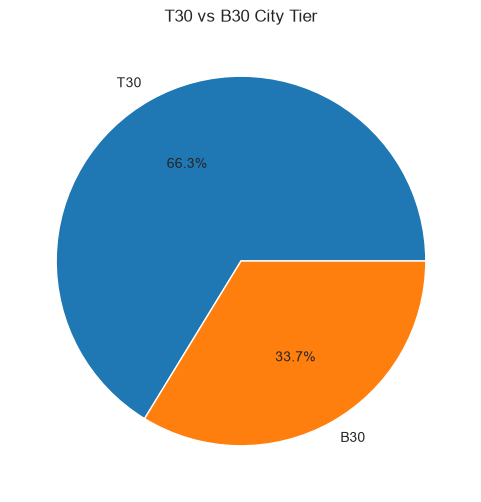

In [76]:
city_counts = investor_df['city_tier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 City Tier")

plt.savefig(
    "../charts/city_tier.png",
    dpi=300
)

plt.show()

In [77]:
selected_funds = nav_merged['scheme_name'].unique()[:10]

corr_data = nav_merged[
    nav_merged['scheme_name'].isin(selected_funds)
]

pivot_df = corr_data.pivot_table(
    index='date',
    columns='scheme_name',
    values='nav'
)

returns = pivot_df.pct_change()

corr_matrix = returns.corr()

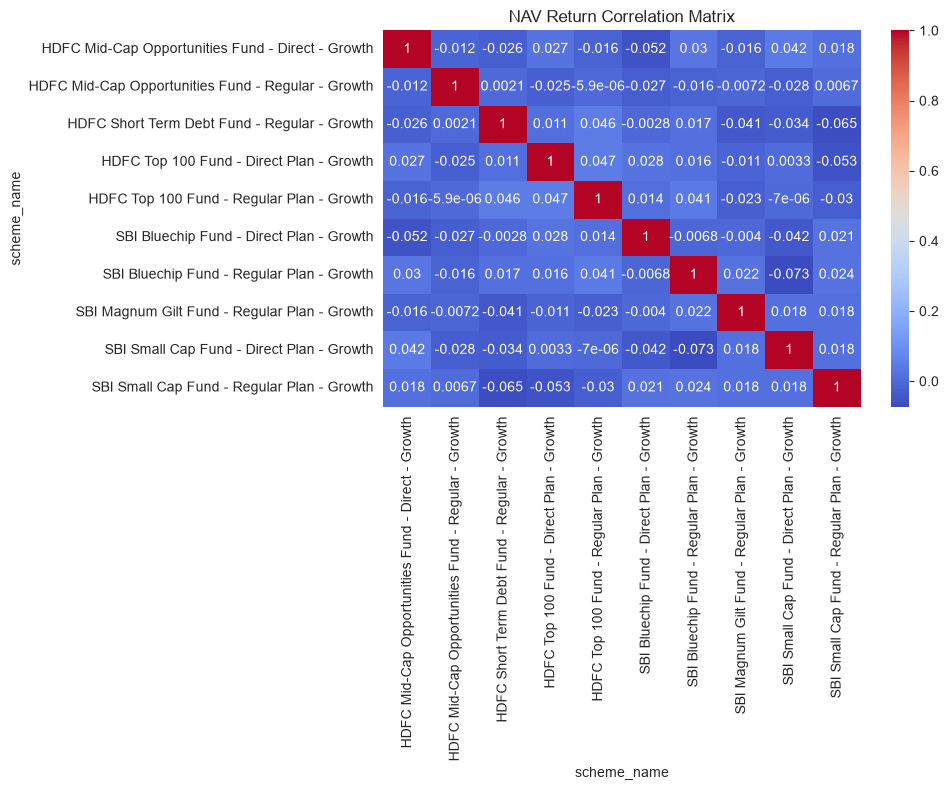

In [78]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../charts/correlation_matrix.png",
    dpi=300
)

plt.show()

1. SIP inflows showed consistent growth from 2022 to 2025.

2. Equity-oriented schemes exhibited strong NAV growth.

3. SBI Mutual Fund maintained a dominant AUM position.

4. Retail participation increased significantly over time.

5. Folio counts nearly doubled during the study period.

6. Younger investors contributed a major share of transactions.

7. T30 cities contributed most investments.

8. Equity funds attracted higher inflows than other categories.

9. Technology and financial sectors had high portfolio allocation.

10. Several equity funds demonstrated strong positive correlations.